# 1. Intro

The Expectation-Maximization (EM) algorithm is a powerful iterative optimization technique used to estimate unknown parameters in probabilistic models, particularly when the data is incomplete, noisy or contains hidden (latent) variables. It works in two steps:

* E-step (Expectation Step): Using the current parameter estimates, the algorithm calculates the expected values of the missing or hidden variables. Essentially, it assigns probabilities or "responsibilities" to different hidden outcomes given the observed data.
* M-step (Maximization Step): With these updated expectations from the E-step, the algorithm then re-estimates the model parameters by maximizing the expected log-likelihood. This improves how well the model explains the observed data.
These two steps are repeated until convergence, which typically means that:

* The parameter values stop changing significantly, or
* The log-likelihood improves only by a negligible amount.

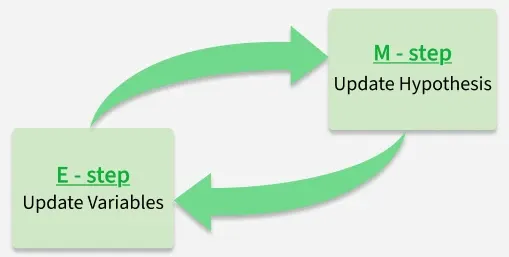

By iteratively repeating these steps the EM algorithm seeks to maximize the likelihood of the observed data.

Key Terms in Expectation-Maximization (EM) Algorithm
Lets understand about some of the most commonly used key terms in the Expectation-Maximization (EM) Algorithm:

* Latent Variables: Variables that are not directly observed but are inferred from the data. They represent hidden structure (e.g., cluster assignments in Gaussian Mixture Models).
* Likelihood: The probability of the observed data given a set of model parameters. EM aims to find parameter values that maximize this likelihood.
* Log-Likelihood: The natural logarithm of the likelihood function. It simplifies calculations (turning products into sums) and is numerically more stable when dealing with very small probabilities.
* Maximum Likelihood Estimation (MLE): A statistical approach to estimating parameters by choosing the values that maximize the likelihood of observing the given data. EM extends MLE to cases with hidden or missing variables.
* Posterior Probability: In Bayesian inference, this represents the probability of parameters (or latent variables) given the observed data and prior knowledge. In EM, posterior probabilities are used in the E-step to estimate the "responsibility" of each hidden variable.
* Convergence: The stopping criterion for the iterative process. EM is said to converge when updates to parameters or improvements in log-likelihood become negligibly small, meaning the algorithm has reached a stable solution.
* Working of Expectation-Maximization (EM) Algorithm
Here's a step-by-step breakdown of the process:

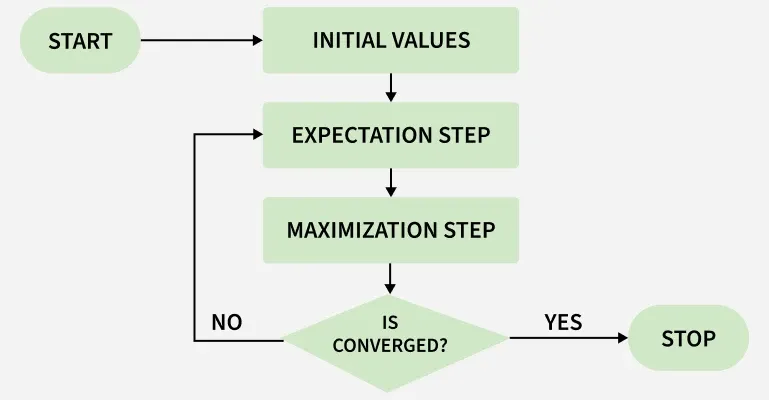

1. Initialization: The algorithm starts with initial parameter values and assumes the observed data comes from a specific model.

2. E-Step (Expectation Step):

Find the missing or hidden data based on the current parameters.
Calculate the posterior probability of each latent variable based on the observed data.
Compute the log-likelihood of the observed data using the current parameter estimates.
3. M-Step (Maximization Step):

Update the model parameters by maximize the log-likelihood.
The better the model the higher this value.
4. Convergence:

Check if the model parameters are stable and converging.
If the changes in log-likelihood or parameters are below a set threshold, stop. If not repeat the E-step and M-step until convergence is reached

# 2. Apply in Python


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

mu1, sigma1 = 2, 1
mu2, sigma2 = -1, 0.8

X1 = np.random.normal(mu1, sigma1, size=200)
X2 = np.random.normal(mu2, sigma2, size=600)
X = np.concatenate([X1, X2])

sns.kdeplot(X)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Density Estimation of X')
plt.show()

mu1_hat, sigma1_hat = np.mean(X1), np.std(X1)
mu2_hat, sigma2_hat = np.mean(X2), np.std(X2)
pi1_hat, pi2_hat = len(X1) / len(X), len(X2) / len(X)

num_epochs = 20
log_likelihoods = []

for epoch in range(num_epochs):
    gamma1 = pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
    gamma2 = pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)
    total = gamma1 + gamma2
    gamma1 /= total
    gamma2 /= total

    mu1_hat = np.sum(gamma1 * X) / np.sum(gamma1)
    mu2_hat = np.sum(gamma2 * X) / np.sum(gamma2)
    sigma1_hat = np.sqrt(np.sum(gamma1 * (X - mu1_hat)**2) / np.sum(gamma1))
    sigma2_hat = np.sqrt(np.sum(gamma2 * (X - mu2_hat)**2) / np.sum(gamma2))
    pi1_hat = np.mean(gamma1)
    pi2_hat = np.mean(gamma2)

    log_likelihood = np.sum(np.log(pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
                                   + pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)))
    log_likelihoods.append(log_likelihood)


plt.plot(range(1, num_epochs + 1), log_likelihoods)
plt.xlabel('Epoch')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs. Epoch')
plt.show()

X_sorted = np.sort(X)
density_estimation = (pi1_hat * norm.pdf(X_sorted, mu1_hat, sigma1_hat) +
                      pi2_hat * norm.pdf(X_sorted, mu2_hat, sigma2_hat))

plt.plot(X_sorted, gaussian_kde(X_sorted)(
    X_sorted), color='green', linewidth=2)
plt.plot(X_sorted, density_estimation, color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Final Density Estimation')
plt.legend(['Kernel Density Estimation', 'Mixture Density'])
plt.show()



# 3. Morre about EM

Applications
* Clustering: Used in Gaussian Mixture Models (GMMs) to assign data points to clusters probabilistically.
* Missing Data Imputation: Helps fill in missing values in datasets by estimating them iteratively.
* Image Processing: Applied in image segmentation, denoising and restoration tasks where pixel classes are hidden.
* Natural Language Processing (NLP): Used in tasks like word alignment in machine translation and topic modeling (LDA).
* Hidden Markov Models (HMMs): EM’s variant, the Baum-Welch algorithm, estimates transition/emission probabilities for sequence data.
Advantages
* Monotonic improvement: Each iteration increases (or at least never decreases) the log-likelihood.
* Handles incomplete data well: Works effectively even with missing or hidden variables.
* Flexibility: Can be applied to many probabilistic models, not just mixtures of Gaussians.
* Easy to implement: The E-step and M-step are conceptually simple and often have closed-form updates.
Disadvantages
* Slow convergence: Convergence can be very gradual, especially near the optimum.
* Initialization sensitive: Requires good initial parameter guesses; poor choices may yield bad solutions.
* No guarantee of global best solution: Unlike some optimization methods, EM doesn’t guarantee reaching the absolute best parameters.
* Computationally intensive: For large datasets or complex models, repeated iterations can be costly.